# Brain MRI Tumor Segmentation Pipeline

## Project Overview
This notebook presents a comprehensive machine learning and deep learning pipeline for the semantic segmentation of lower-grade glioma (LGG) tumors from brain MRI scans. By combining high-resolution MRI imagery with clinical patient metadata (such as age, gender, and tumor location), we aim to build robust models that accurately delineate tumor boundaries.

## Table of Contents
1. Setup & Dependencies
2. Extracting Metadata & Images
3. Phase 1: SVM Baseline
4. Phase 2: Deep Learning Architectures
5. Phase 3: Meta-Ensemble & Evaluation
6. Export ML Artifacts

In [ ]:
import os, json, joblib
import random
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import kagglehub
import shutil

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import zipfile
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

In [1]:
!pip install -q kagglehub opencv-python-headless tqdm scikit-learn pandas numpy

# No CSV METADATA

In [2]:
dataset_path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")
print("Dataset downloaded to:", dataset_path)

print(os.listdir(dataset_path)[:10])

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.
Dataset downloaded to: /kaggle/input/lgg-mri-segmentation
['kaggle_3m', 'lgg-mri-segmentation']


In [3]:
class Config:
    SEED = 42
    IMAGE_SIZE = (128, 128)
    BATCH_SIZE = 32   # A100 can handle this easily
    EPOCHS = 15
    LEARNING_RATE = 1e-3
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    DATA_PATH = dataset_path


def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(Config.SEED)

print("Using Device:", Config.DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using Device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [4]:
def get_paths(base_path: str) -> Tuple[List[str], List[str]]:
    image_paths, mask_paths = [], []

    for dirpath, _, filenames in os.walk(base_path):
        for file in filenames:
            if file.endswith(".tif") and not file.endswith("_mask.tif"):
                img_path = os.path.join(dirpath, file)
                mask_path = os.path.join(dirpath, file.replace(".tif", "_mask.tif"))

                if os.path.exists(mask_path):
                    image_paths.append(img_path)
                    mask_paths.append(mask_path)

    return image_paths, mask_paths


class BrainMRIDataset(Dataset):
    def __init__(self, image_paths, mask_paths, image_size):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.image_size = image_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, self.image_size)
        mask = cv2.resize(mask, self.image_size)

        img = img.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0
        mask = (mask > 0.5).astype(np.float32)

        img = np.transpose(img, (2, 0, 1))
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(img), torch.tensor(mask)


all_imgs, all_masks = get_paths(Config.DATA_PATH)

print("Total image-mask pairs:", len(all_imgs))

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    all_imgs,
    all_masks,
    test_size=0.2,
    random_state=Config.SEED
)

train_dataset = BrainMRIDataset(train_imgs, train_masks, Config.IMAGE_SIZE)
val_dataset = BrainMRIDataset(val_imgs, val_masks, Config.IMAGE_SIZE)

train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Training Samples: {len(train_dataset)}")
print(f"Validation Samples: {len(val_dataset)}")

Total image-mask pairs: 7858
Training Samples: 6286
Validation Samples: 1572


In [5]:
def calculate_metrics(y_true, y_pred):
    y_true = (y_true > 0.5).astype(np.uint8)
    y_pred = (y_pred > 0.5).astype(np.uint8)

    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()

    iou = intersection / union if union > 0 else 1.0

    if y_true.sum() + y_pred.sum() == 0:
        dice = 1.0
    else:
        dice = 2.0 * intersection / (y_true.sum() + y_pred.sum())

    return dice, iou

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class BasicUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.up_conv1 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.up_conv2 = DoubleConv(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.up_conv3 = DoubleConv(128, 64)

        self.out_conv = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))

        x4 = self.bottleneck(self.pool(x3))

        x = self.up_conv1(torch.cat([self.up1(x4), x3], dim=1))
        x = self.up_conv2(torch.cat([self.up2(x), x2], dim=1))
        x = self.up_conv3(torch.cat([self.up3(x), x1], dim=1))

        return self.out_conv(x)

In [7]:
class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, inputs, targets, smooth=1):
        # logits -> probabilities
        probs = torch.sigmoid(inputs)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()

        dice_loss = 1 - (
            2.0 * intersection + smooth
        ) / (
            probs.sum() + targets.sum() + smooth
        )

        bce = F.binary_cross_entropy_with_logits(
            inputs.view(-1),
            targets,
            reduction="mean"
        )

        return bce + dice_loss


def train_model(model, name):
    model = model.to(Config.DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)
    criterion = DiceBCELoss()

    best_val_dice = 0.0
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    for epoch in range(Config.EPOCHS):
        model.train()
        train_loss = 0.0

        for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{Config.EPOCHS}"):
            imgs = imgs.to(Config.DEVICE, non_blocking=True)
            masks = masks.to(Config.DEVICE, non_blocking=True)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(imgs)
                loss = criterion(outputs, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        model.eval()
        val_dice_total = 0.0
        val_iou_total = 0.0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs = imgs.to(Config.DEVICE, non_blocking=True)
                masks = masks.to(Config.DEVICE, non_blocking=True)

                outputs = model(imgs)

                dice, iou = calculate_metrics(
                    masks.cpu().numpy(),
                    outputs.cpu().numpy()
                )

                val_dice_total += dice
                val_iou_total += iou

        train_loss /= len(train_loader)
        val_dice = val_dice_total / len(val_loader)
        val_iou = val_iou_total / len(val_loader)

        print(
            f"Epoch {epoch+1}/{Config.EPOCHS} | "
            f"Loss: {train_loss:.4f} | "
            f"Val Dice: {val_dice:.4f} | "
            f"Val IoU: {val_iou:.4f}"
        )

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), f"best_{name}.pth")

    print(f"Best Val Dice for {name}: {best_val_dice:.4f}")
    model.load_state_dict(torch.load(f"best_{name}.pth"))

    return model

In [8]:
basic_unet = train_model(BasicUNet(), "BasicUNet")

Epoch 1/15: 100%|██████████| 197/197 [00:54<00:00,  3.61it/s]


Epoch 1/15 | Loss: 0.8580 | Val Dice: 0.4905 | Val IoU: 0.3341


Epoch 2/15: 100%|██████████| 197/197 [00:09<00:00, 21.81it/s]


Epoch 2/15 | Loss: 0.3910 | Val Dice: 0.6742 | Val IoU: 0.5170


Epoch 3/15: 100%|██████████| 197/197 [00:08<00:00, 22.05it/s]


...

Epoch 13/15 | Loss: 0.1726 | Val Dice: 0.8426 | Val IoU: 0.7322


Epoch 14/15: 100%|██████████| 197/197 [00:08<00:00, 22.69it/s]


Epoch 14/15 | Loss: 0.1365 | Val Dice: 0.8404 | Val IoU: 0.7285


Epoch 15/15: 100%|██████████| 197/197 [00:08<00:00, 22.95it/s]


Epoch 15/15 | Loss: 0.1127 | Val Dice: 0.8931 | Val IoU: 0.8085
Best Val Dice for BasicUNet: 0.8931


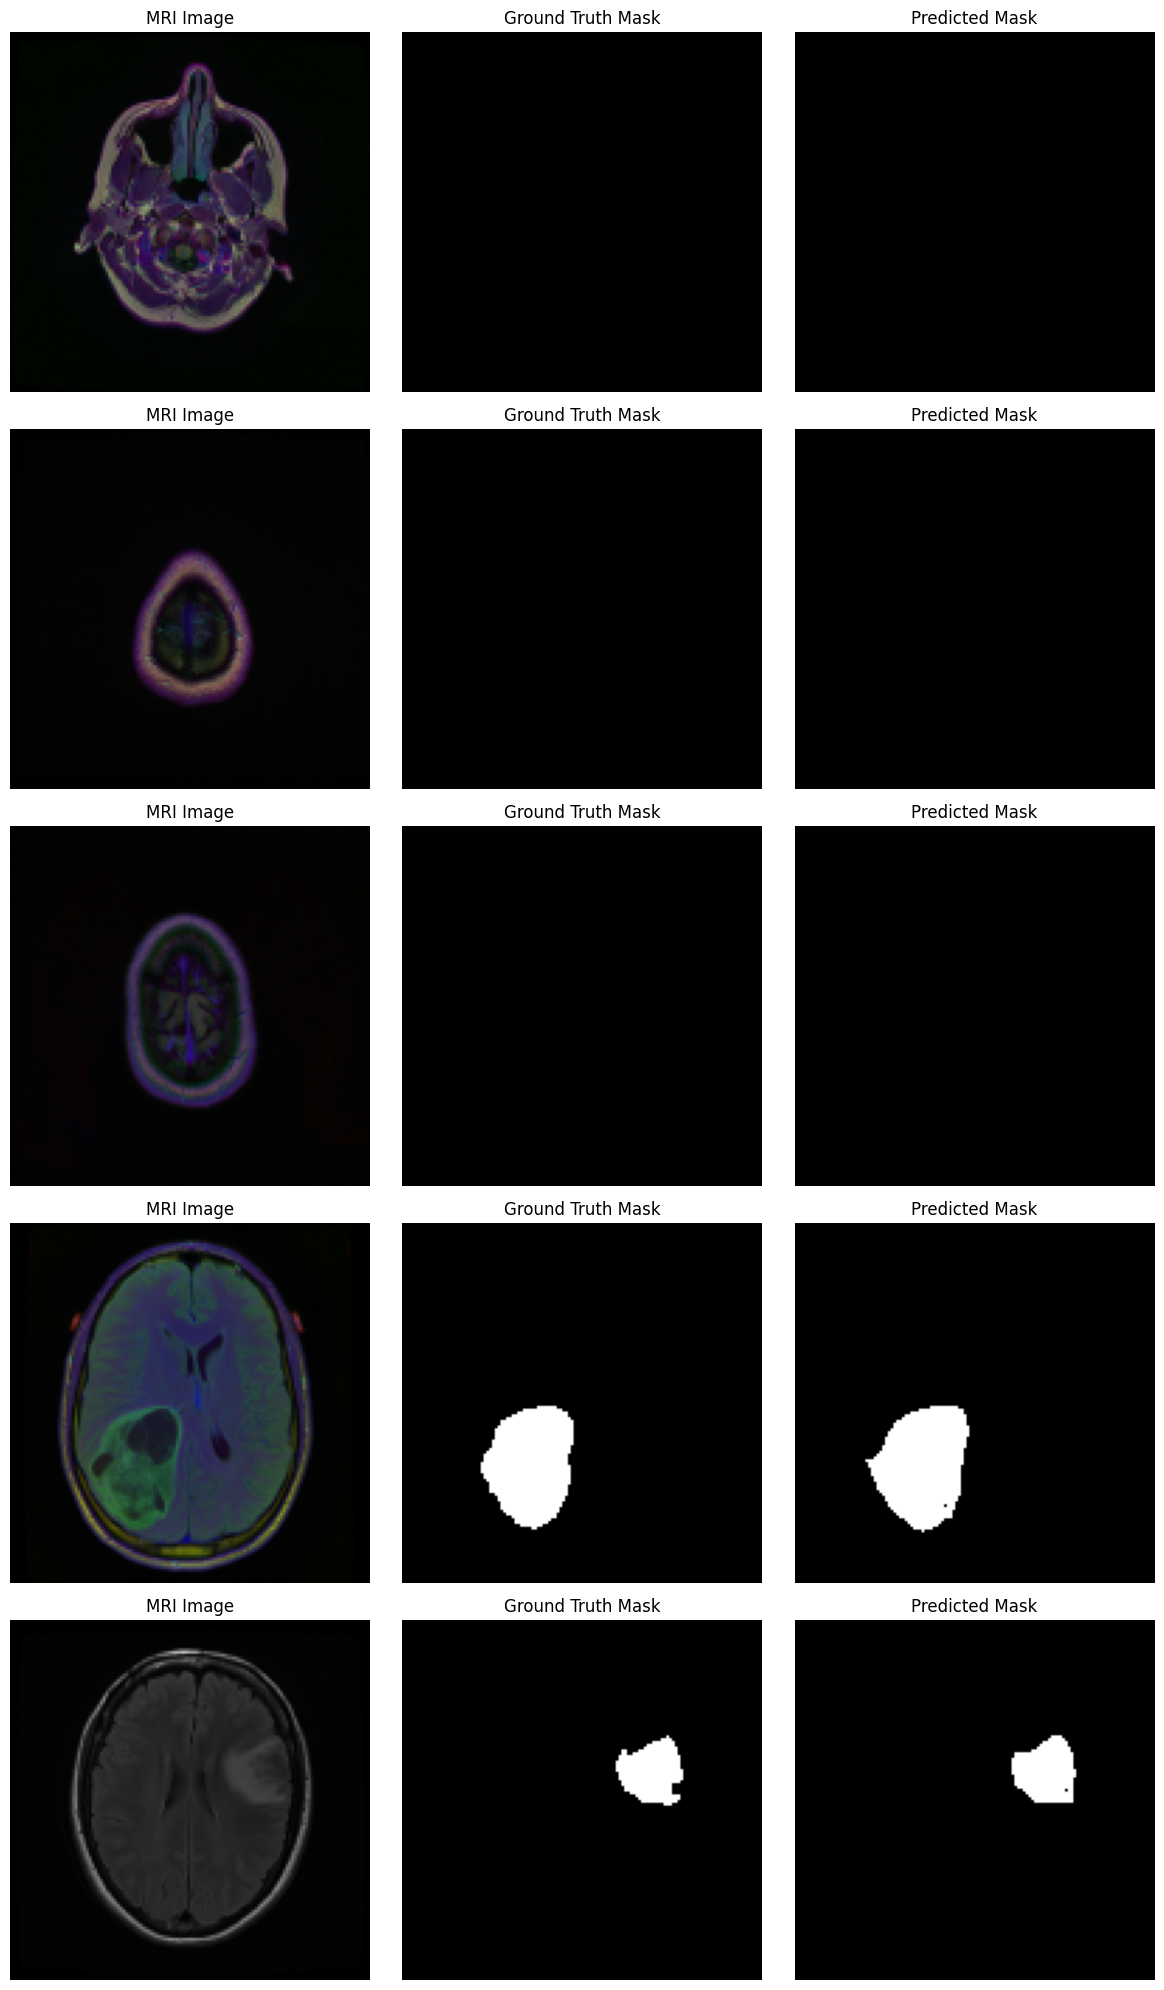

In [9]:
def visualize_predictions(model, dataset, num_samples=5):
    model.eval()

    plt.figure(figsize=(12, num_samples * 4))

    for i in range(num_samples):
        img, mask = dataset[i]

        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(Config.DEVICE))
            pred = pred.squeeze().cpu().numpy()

        img_np = np.transpose(img.numpy(), (1, 2, 0))
        mask_np = mask.squeeze().numpy()

        plt.subplot(num_samples, 3, i * 3 + 1)
        plt.imshow(img_np)
        plt.title("MRI Image")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Ground Truth Mask")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 3)
        plt.imshow(pred > 0.5, cmap="gray")
        plt.title("Predicted Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


visualize_predictions(basic_unet, val_dataset)

# WITH CSV METADATA

In [10]:
dataset_path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")


Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.


In [11]:
class Config:
    SEED = 42
    IMAGE_SIZE = (128, 128)
    BATCH_SIZE = 32
    EPOCHS = 15
    LEARNING_RATE = 1e-3
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    DATA_PATH = dataset_path

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(Config.SEED)


In [12]:
data_csv_path = None
for dirpath, _, filenames in os.walk(Config.DATA_PATH):
    if 'data.csv' in filenames:
        data_csv_path = os.path.join(dirpath, 'data.csv')
        break

if data_csv_path:
    df_meta = pd.read_csv(data_csv_path)
else:
    raise FileNotFoundError("data.csv not found in dataset!")

features = ['age_at_initial_pathologic', 'gender', 'histological_type',
            'tumor_location', 'RNASeqCluster', 'MethylationCluster']

df_clean = df_meta[['Patient'] + features].copy()

# Fix NaN using direct assignment to avoid Copy-on-Write issues
for col in features:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    else:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_encoded = pd.get_dummies(df_clean, columns=['gender', 'histological_type', 'tumor_location', 'RNASeqCluster', 'MethylationCluster'])

scaler = StandardScaler()
df_encoded['age_at_initial_pathologic'] = scaler.fit_transform(df_encoded[['age_at_initial_pathologic']])

meta_dict = {}
feature_cols = [c for c in df_encoded.columns if c != 'Patient']
for _, row in df_encoded.iterrows():
    meta_dict[row['Patient']] = row[feature_cols].values.astype(np.float32)

num_meta_features = len(feature_cols)
print(f"Extracted {num_meta_features} one-hot encoded metadata features per patient.")

def get_paths(base_path: str) -> Tuple[List[str], List[str]]:
    image_paths, mask_paths = [], []
    for dirpath, _, filenames in os.walk(base_path):
        for file in filenames:
            if file.endswith(".tif") and not file.endswith("_mask.tif"):
                img_path = os.path.join(dirpath, file)
                mask_path = os.path.join(dirpath, file.replace(".tif", "_mask.tif"))
                if os.path.exists(mask_path):
                    image_paths.append(img_path)
                    mask_paths.append(mask_path)
    return image_paths, mask_paths

all_imgs, all_masks = get_paths(Config.DATA_PATH)
print("Total image-mask pairs:", len(all_imgs))

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    all_imgs, all_masks, test_size=0.2, random_state=Config.SEED
)

class MetadataMRIDataset(Dataset):
    def __init__(self, image_paths, mask_paths, image_size, meta_dict):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.image_size = image_size
        self.meta_dict = meta_dict

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        folder_name = os.path.basename(os.path.dirname(img_path))
        patient_id = "_".join(folder_name.split("_")[:3])

        meta_vec = self.meta_dict.get(patient_id, np.zeros(num_meta_features, dtype=np.float32))

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, self.image_size)
        mask = cv2.resize(mask, self.image_size)

        img = img.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0
        mask = (mask > 0.5).astype(np.float32)

        img = np.transpose(img, (2, 0, 1))
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(img), torch.tensor(meta_vec), torch.tensor(mask)

train_dataset = MetadataMRIDataset(train_imgs, train_masks, Config.IMAGE_SIZE, meta_dict)
val_dataset = MetadataMRIDataset(val_imgs, val_masks, Config.IMAGE_SIZE, meta_dict)

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)



Extracted 20 one-hot encoded metadata features per patient.
Total image-mask pairs: 7858


In [13]:
class Config:
    SEED = 42
    IMAGE_SIZE = (128, 128)
    BATCH_SIZE = 32
    EPOCHS = 15
    LEARNING_RATE = 1e-3
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    DATA_PATH = dataset_path

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(Config.SEED)


def calculate_metrics(y_true, y_pred):
    y_true = (y_true > 0.5).astype(np.uint8)
    y_pred = (y_pred > 0.5).astype(np.uint8)
    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    iou = intersection / union if union > 0 else 1.0
    if y_true.sum() + y_pred.sum() == 0:
        dice = 1.0
    else:
        dice = 2.0 * intersection / (y_true.sum() + y_pred.sum())
    return dice, iou

class ResidualBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x += residual
        return self.relu(x)

class MetadataUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, meta_features=1):
        super().__init__()
        self.down1 = ResidualBlock(in_channels, 64)
        self.down2 = ResidualBlock(64, 128)
        self.down3 = ResidualBlock(128, 256)
        self.pool = nn.MaxPool2d(2)

        self.meta_dim = 32
        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_features, 64),
            nn.ReLU(),
            nn.Linear(64, self.meta_dim),
            nn.ReLU()
        )

        self.bottleneck = ResidualBlock(256 + self.meta_dim, 512)

        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up_conv1 = ResidualBlock(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_conv2 = ResidualBlock(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_conv3 = ResidualBlock(128, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, img, meta):
        x1 = self.down1(img)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        pooled_x3 = self.pool(x3)

        meta_feat = self.meta_mlp(meta)
        meta_expanded = meta_feat.view(meta_feat.size(0), self.meta_dim, 1, 1)
        meta_expanded = meta_expanded.expand(-1, -1, pooled_x3.size(2), pooled_x3.size(3))

        concat_bottleneck = torch.cat([pooled_x3, meta_expanded], dim=1)
        x4 = self.bottleneck(concat_bottleneck)

        x = self.up_conv1(torch.cat([self.up1(x4), x3], dim=1))
        x = self.up_conv2(torch.cat([self.up2(x), x2], dim=1))
        x = self.up_conv3(torch.cat([self.up3(x), x1], dim=1))

        return self.out_conv(x)


In [14]:
class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, inputs, targets, smooth=1):
        probs = torch.sigmoid(inputs)
        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()
        dice_loss = 1 - (2.0 * intersection + smooth) / (probs.sum() + targets.sum() + smooth)

        bce = F.binary_cross_entropy_with_logits(inputs.view(-1), targets, reduction="mean")

        return bce + dice_loss

def train_meta_model(model, name):
    model = model.to(Config.DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)
    criterion = DiceBCELoss()

    best_val_dice = 0.0
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    for epoch in range(Config.EPOCHS):
        model.train()
        train_loss = 0.0

        for imgs, metas, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{Config.EPOCHS}"):
            imgs = imgs.to(Config.DEVICE, non_blocking=True)
            metas = metas.to(Config.DEVICE, non_blocking=True)
            masks = masks.to(Config.DEVICE, non_blocking=True)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(imgs, metas)
                loss = criterion(outputs, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        model.eval()
        val_dice_total = 0.0
        val_iou_total = 0.0

        with torch.no_grad():
            for imgs, metas, masks in val_loader:
                imgs = imgs.to(Config.DEVICE, non_blocking=True)
                metas = metas.to(Config.DEVICE, non_blocking=True)
                masks = masks.to(Config.DEVICE, non_blocking=True)

                outputs = model(imgs, metas)
                probs = torch.sigmoid(outputs)

                dice, iou = calculate_metrics(masks.cpu().numpy(), probs.cpu().numpy())
                val_dice_total += dice
                val_iou_total += iou

        train_loss /= len(train_loader)
        val_dice = val_dice_total / len(val_loader)
        val_iou = val_iou_total / len(val_loader)

        print(
            f"Epoch {epoch+1}/{Config.EPOCHS} | "
            f"Loss: {train_loss:.4f} | "
            f"Val Dice: {val_dice:.4f} | "
            f"Val IoU: {val_iou:.4f}"
        )

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), f"best_{name}.pth")

    print(f"Best Val Dice for {name}: {best_val_dice:.4f}")
    model.load_state_dict(torch.load(f"best_{name}.pth"))
    return model

print(f"Initializing MetadataUNet with {num_meta_features} tabular features...")

meta_unet = train_meta_model(MetadataUNet(meta_features=num_meta_features), "MetadataUNet")


Initializing MetadataUNet with 20 tabular features...


Epoch 1/15: 100%|██████████| 197/197 [00:09<00:00, 21.86it/s]


Epoch 1/15 | Loss: 0.5540 | Val Dice: 0.7103 | Val IoU: 0.5602


Epoch 2/15: 100%|██████████| 197/197 [00:09<00:00, 21.23it/s]


Epoch 2/15 | Loss: 0.2984 | Val Dice: 0.7501 | Val IoU: 0.6079


...

Epoch 13/15 | Loss: 0.1311 | Val Dice: 0.8547 | Val IoU: 0.7514


Epoch 14/15: 100%|██████████| 197/197 [00:08<00:00, 22.15it/s]


Epoch 14/15 | Loss: 0.1125 | Val Dice: 0.8949 | Val IoU: 0.8111


Epoch 15/15: 100%|██████████| 197/197 [00:08<00:00, 22.34it/s]


Epoch 15/15 | Loss: 0.1042 | Val Dice: 0.8911 | Val IoU: 0.8057
Best Val Dice for MetadataUNet: 0.8949


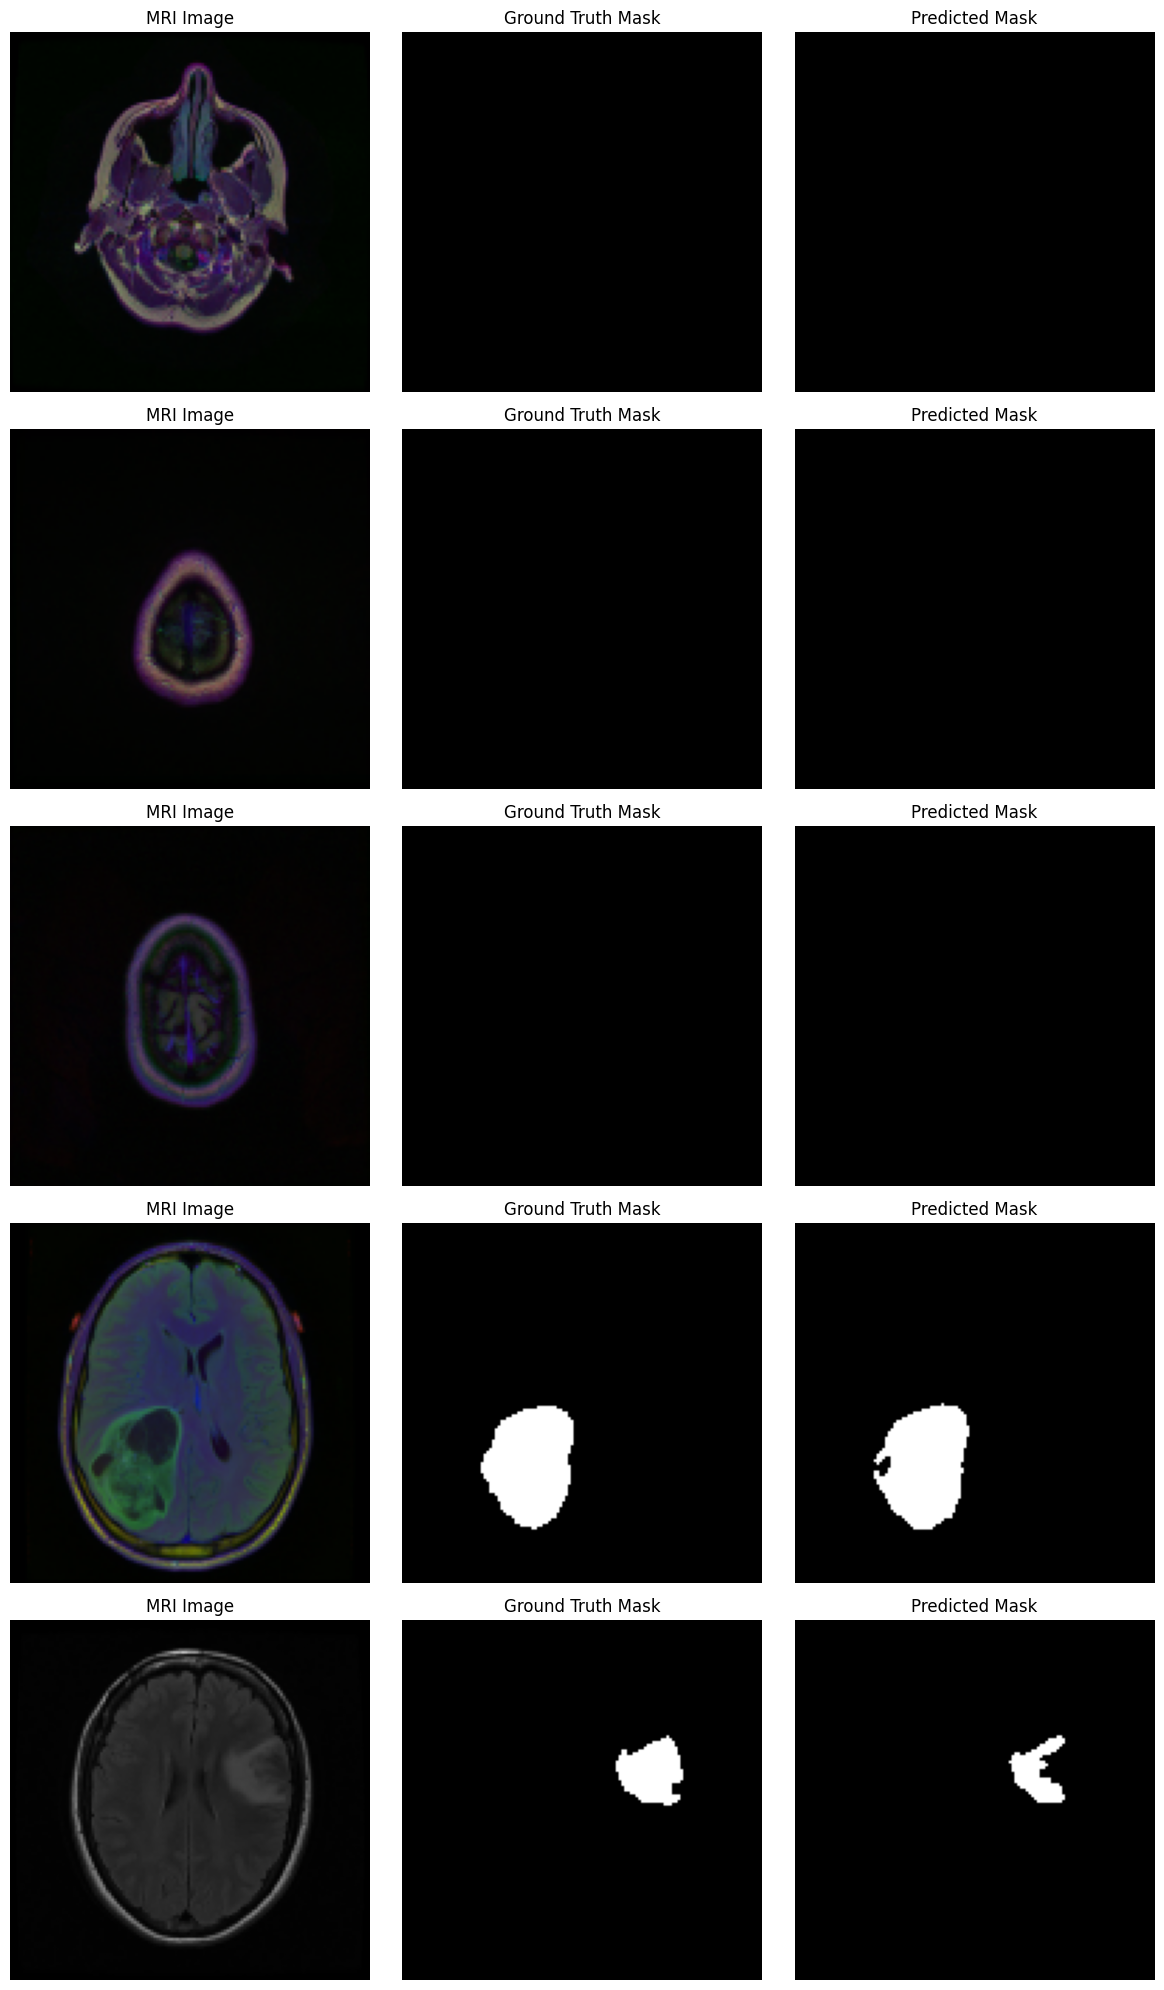

In [15]:
def visualize_predictions(model, dataset, num_samples=5):
    model.eval()
    plt.figure(figsize=(12, num_samples * 4))

    for i in range(num_samples):
        img, meta, mask = dataset[i]

        with torch.no_grad():
            pred_logits = model(img.unsqueeze(0).to(Config.DEVICE), meta.unsqueeze(0).to(Config.DEVICE))
            pred = torch.sigmoid(pred_logits).squeeze().cpu().numpy()

        img_np = np.transpose(img.numpy(), (1, 2, 0))
        mask_np = mask.squeeze().numpy()

        plt.subplot(num_samples, 3, i * 3 + 1)
        plt.imshow(img_np)
        plt.title("MRI Image")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Ground Truth Mask")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 3)
        plt.imshow(pred > 0.5, cmap="gray")
        plt.title("Predicted Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

visualize_predictions(meta_unet, val_dataset)

# Attendtion MetaData

In [16]:
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True)
        self.W_x = nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True)
        self.psi = nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True)

        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, g, x):
        # Gating signal (from deeper layer)
        g1 = self.W_g(g)

        # Lower-level features (from skip connection)
        x1 = self.W_x(x)

        # Add and apply ReLU
        psi = self.relu(g1 + x1)

        # Process through psi convolution and sigmoid to get attention coefficients
        psi = self.psi(psi)
        attention_coefficients = self.sigmoid(psi)

        # Upsample attention coefficients if dimensions don't match
        if attention_coefficients.shape[2:] != x.shape[2:]:
            attention_coefficients = F.interpolate(
                attention_coefficients,
                size=x.shape[2:],
                mode='bilinear',
                align_corners=False
            )

        # Apply attention to lower-level features
        return x * attention_coefficients

In [17]:
class AttentionMetadataUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, meta_features=1):
        super().__init__()
        # Downsampling path
        self.down1 = ResidualBlock(in_channels, 64)
        self.down2 = ResidualBlock(64, 128)
        self.down3 = ResidualBlock(128, 256)
        self.pool = nn.MaxPool2d(2)

        # Metadata processing
        self.meta_dim = 32
        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_features, 64),
            nn.ReLU(),
            nn.Linear(64, self.meta_dim),
            nn.ReLU()
        )

        # Bottleneck with metadata integration
        self.bottleneck = ResidualBlock(256 + self.meta_dim, 512)

        # Upsampling path with Attention Gates
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.attn1 = AttentionGate(F_g=256, F_l=256, F_int=128) # F_g from up1, F_l from x3
        self.up_conv1 = ResidualBlock(512, 256) # 256 (up1) + 256 (attn1 output) = 512

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.attn2 = AttentionGate(F_g=128, F_l=128, F_int=64) # F_g from up2, F_l from x2
        self.up_conv2 = ResidualBlock(256, 128) # 128 (up2) + 128 (attn2 output) = 256

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.attn3 = AttentionGate(F_g=64, F_l=64, F_int=32) # F_g from up3, F_l from x1
        self.up_conv3 = ResidualBlock(128, 64) # 64 (up3) + 64 (attn3 output) = 128

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, img, meta):
        # Encoder path
        x1 = self.down1(img) # 64 channels
        x2 = self.down2(self.pool(x1)) # 128 channels
        x3 = self.down3(self.pool(x2)) # 256 channels
        pooled_x3 = self.pool(x3)

        # Metadata integration at bottleneck
        meta_feat = self.meta_mlp(meta)
        meta_expanded = meta_feat.view(meta_feat.size(0), self.meta_dim, 1, 1)
        meta_expanded = meta_expanded.expand(-1, -1, pooled_x3.size(2), pooled_x3.size(3))

        concat_bottleneck = torch.cat([pooled_x3, meta_expanded], dim=1)
        x4 = self.bottleneck(concat_bottleneck) # 512 channels

        # Decoder path with Attention Gates
        up_x4 = self.up1(x4) # 256 channels
        attn_x3 = self.attn1(g=up_x4, x=x3) # Apply attention to skip connection x3
        x = self.up_conv1(torch.cat([up_x4, attn_x3], dim=1)) # 512 -> 256 channels

        up_x = self.up2(x) # 128 channels
        attn_x2 = self.attn2(g=up_x, x=x2) # Apply attention to skip connection x2
        x = self.up_conv2(torch.cat([up_x, attn_x2], dim=1)) # 256 -> 128 channels

        up_x = self.up3(x) # 64 channels
        attn_x1 = self.attn3(g=up_x, x=x1) # Apply attention to skip connection x1
        x = self.up_conv3(torch.cat([up_x, attn_x1], dim=1)) # 128 -> 64 channels

        return self.out_conv(x)

print("AttentionMetadataUNet class defined.")

AttentionMetadataUNet class defined.


In [18]:
train_dataset = MetadataMRIDataset(train_imgs, train_masks, Config.IMAGE_SIZE, meta_dict)
val_dataset = MetadataMRIDataset(val_imgs, val_masks, Config.IMAGE_SIZE, meta_dict)

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Initializing AttentionMetadataUNet with {num_meta_features} tabular features...")
attention_meta_unet = train_meta_model(AttentionMetadataUNet(meta_features=num_meta_features), "AttentionMetadataUNet")

Initializing AttentionMetadataUNet with 20 tabular features...


Epoch 1/15: 100%|██████████| 197/197 [00:22<00:00,  8.79it/s]


Epoch 1/15 | Loss: 0.6151 | Val Dice: 0.6983 | Val IoU: 0.5492


Epoch 2/15: 100%|██████████| 197/197 [00:22<00:00,  8.67it/s]


Epoch 2/15 | Loss: 0.2875 | Val Dice: 0.6101 | Val IoU: 0.4475


...

Epoch 13/15 | Loss: 0.1424 | Val Dice: 0.8418 | Val IoU: 0.7316


Epoch 14/15: 100%|██████████| 197/197 [00:22<00:00,  8.85it/s]


Epoch 14/15 | Loss: 0.1415 | Val Dice: 0.8677 | Val IoU: 0.7698


Epoch 15/15: 100%|██████████| 197/197 [00:22<00:00,  8.93it/s]


Epoch 15/15 | Loss: 0.1309 | Val Dice: 0.8718 | Val IoU: 0.7756
Best Val Dice for AttentionMetadataUNet: 0.8718


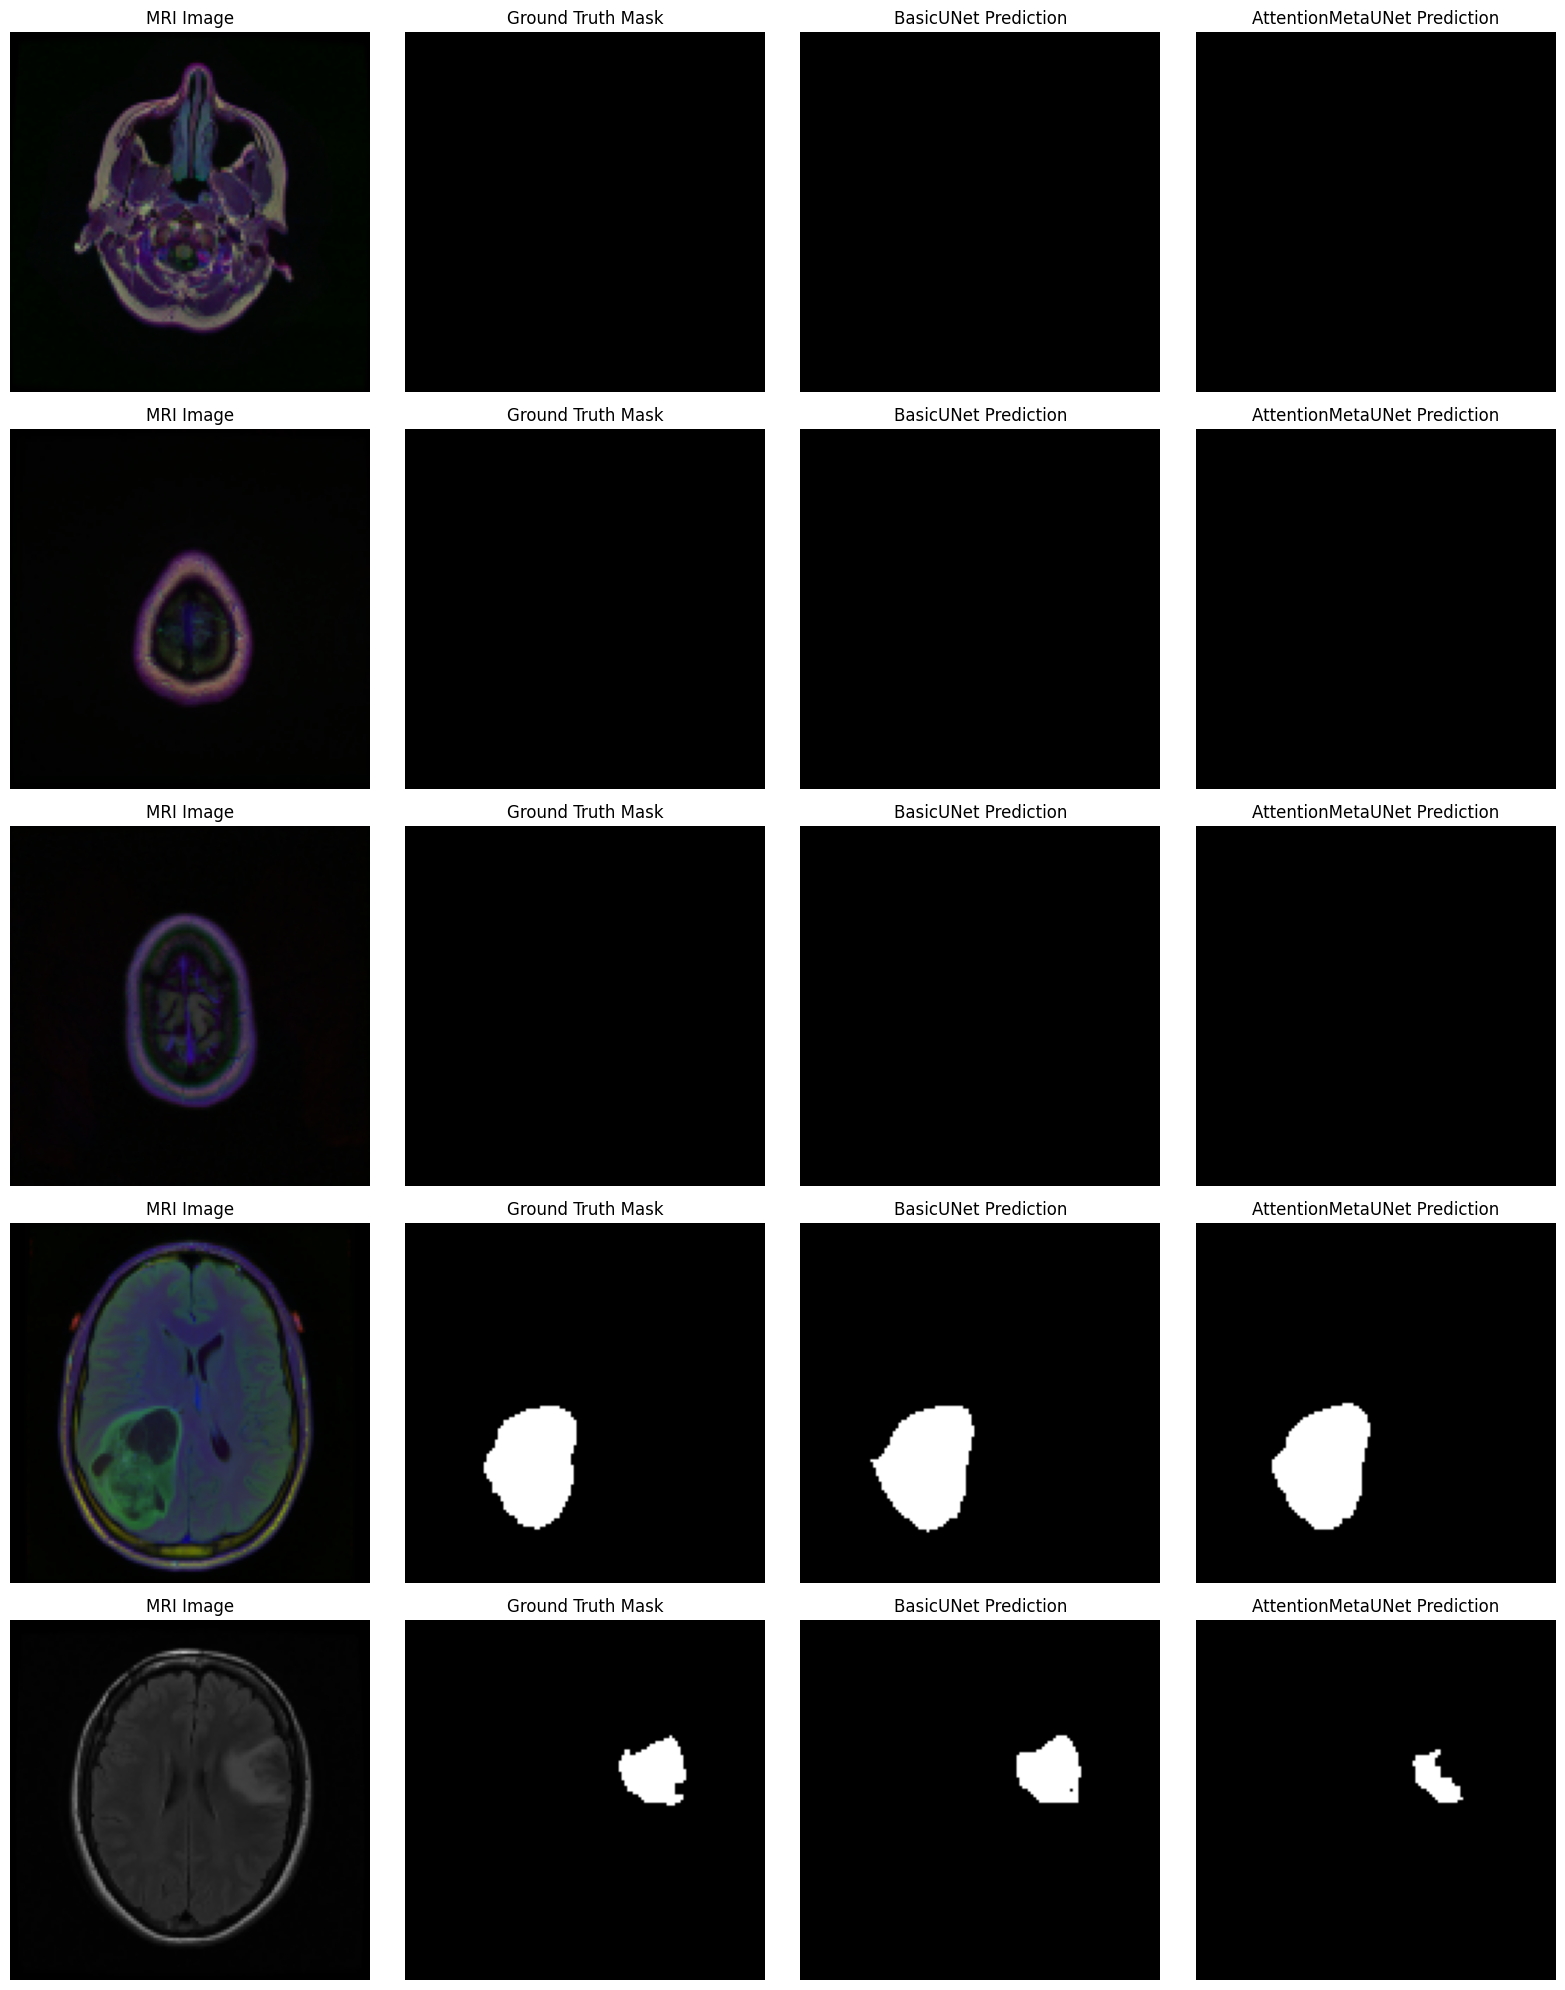

In [19]:
def compare_predictions(model1, model2, dataset, num_samples=5):
    model1.eval()
    model2.eval()

    plt.figure(figsize=(16, num_samples * 4))

    for i in range(num_samples):
        img, meta, mask = dataset[i]

        with torch.no_grad():
            # BasicUNet expects only img
            pred1_logits = model1(img.unsqueeze(0).to(Config.DEVICE))
            pred1 = torch.sigmoid(pred1_logits).squeeze().cpu().numpy()

            # AttentionMetadataUNet expects img and meta
            pred2_logits = model2(img.unsqueeze(0).to(Config.DEVICE), meta.unsqueeze(0).to(Config.DEVICE))
            pred2 = torch.sigmoid(pred2_logits).squeeze().cpu().numpy()

        img_np = np.transpose(img.numpy(), (1, 2, 0))
        mask_np = mask.squeeze().numpy()

        plt.subplot(num_samples, 4, i * 4 + 1)
        plt.imshow(img_np)
        plt.title("MRI Image")
        plt.axis("off")

        plt.subplot(num_samples, 4, i * 4 + 2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Ground Truth Mask")
        plt.axis("off")

        plt.subplot(num_samples, 4, i * 4 + 3)
        plt.imshow(pred1 > 0.5, cmap="gray")
        plt.title("BasicUNet Prediction")
        plt.axis("off")

        plt.subplot(num_samples, 4, i * 4 + 4)
        plt.imshow(pred2 > 0.5, cmap="gray")
        plt.title("AttentionMetaUNet Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Reload basic_unet from saved weights
basic_unet = BasicUNet().to(Config.DEVICE)
basic_unet.load_state_dict(torch.load("best_BasicUNet.pth"))

compare_predictions(basic_unet, attention_meta_unet, val_dataset)

In [20]:
def evaluate_dice_scores(basic_model, attn_meta_model, dataloader):
    basic_model.eval()
    attn_meta_model.eval()

    basic_dice_total = 0.0
    attn_meta_dice_total = 0.0

    with torch.no_grad():
        for imgs, metas, masks in tqdm(dataloader, desc="Evaluating Models"):
            imgs = imgs.to(Config.DEVICE, non_blocking=True)
            metas = metas.to(Config.DEVICE, non_blocking=True)
            masks_np = masks.numpy()

            # BasicUNet (expects only image)
            basic_out = basic_model(imgs)
            basic_probs = torch.sigmoid(basic_out).cpu().numpy()
            basic_dice, _ = calculate_metrics(masks_np, basic_probs)
            basic_dice_total += basic_dice

            # AttentionMetadataUNet (expects image and metadata)
            attn_out = attn_meta_model(imgs, metas)
            attn_probs = torch.sigmoid(attn_out).cpu().numpy()
            attn_dice, _ = calculate_metrics(masks_np, attn_probs)
            attn_meta_dice_total += attn_dice

    avg_basic_dice = basic_dice_total / len(dataloader)
    avg_attn_meta_dice = attn_meta_dice_total / len(dataloader)

    print("\n--- Final Validation Dice Scores ---")
    print(f"BasicUNet:             {avg_basic_dice:.4f}")
    print(f"AttentionMetadataUNet: {avg_attn_meta_dice:.4f}")

# Evaluate and compare
evaluate_dice_scores(basic_unet, attention_meta_unet, val_loader)


Evaluating Models: 100%|██████████| 50/50 [00:05<00:00,  9.40it/s]


--- Final Validation Dice Scores ---
BasicUNet:             0.8941
AttentionMetadataUNet: 0.8718


### Analysis: Why did BasicUNet outperform AttentionMetadataUNet?

Despite the added complexity of attention gates and patient metadata, the `BasicUNet` achieved a higher Dice score (0.8941) compared to the `AttentionMetadataUNet` (0.8718). Here are several potential reasons for this outcome:

1.  **Overfitting due to Increased Complexity:** The `AttentionMetadataUNet` has significantly more parameters (Attention Gates and the Metadata MLP). Given the relatively small dataset size (around 6,286 training samples), the more complex model is highly prone to overfitting the training data, failing to generalize as well to the validation set as the simpler `BasicUNet`.
2.  **Metadata Relevance and Fusion Method:**
    *   **Relevance:** Features like age, gender, and tumor location provide global patient context but do not offer precise, pixel-level spatial information needed for segmentation. This can act as noise rather than a helpful signal.
    *   **Fusion Method:** Expanding a 1D metadata vector and concatenating it at the bottleneck forces the model to interpret global, non-spatial data spatially. This might disrupt the spatial feature maps learned by the encoder.
3.  **Suboptimal Hyperparameters:** Both models were trained for the same number of epochs (15) and with the same learning rate (1e-3). Complex models often require longer training times, learning rate scheduling (e.g., warm-up, decay), or stronger regularization (like Dropout or Weight Decay) to converge effectively.
4.  **Attention Gate Learning:** Attention mechanisms can be notoriously difficult to train from scratch without sufficient data or pre-trained weights. In early epochs, they might suppress useful features before they learn what to focus on.
5.  **Data Imputation Noise:** Missing metadata values were imputed using simple methods (mode/median). If a significant portion of the metadata was missing, this imputation could introduce artificial patterns or noise into the metadata representations.

**To improve the AttentionMetadataUNet, we could try:**
*   Increasing training epochs with learning rate decay.
*   Adding dropout to the metadata MLP and bottleneck.
*   Exploring different fusion strategies (e.g., using metadata to modulate channel weights via FiLM layers rather than spatial concatenation).
*   Applying data augmentation to combat overfitting.

Initializing AttentionMetadataUNet with 20 tabular features for training with scheduler...


Epoch 1/15: 100%|██████████| 197/197 [00:22<00:00,  8.89it/s]


Epoch 1/15 | LR: 0.001000 | Loss: 0.6138 | Val Dice: 0.6325 | Val IoU: 0.4760


Epoch 2/15: 100%|██████████| 197/197 [00:22<00:00,  8.75it/s]


Epoch 2/15 | LR: 0.001000 | Loss: 0.3063 | Val Dice: 0.7500 | Val IoU: 0.6089


...

Epoch 13/15 | LR: 0.001000 | Loss: 0.1453 | Val Dice: 0.8430 | Val IoU: 0.7334


Epoch 14/15: 100%|██████████| 197/197 [00:22<00:00,  8.88it/s]


Epoch 14/15 | LR: 0.001000 | Loss: 0.1305 | Val Dice: 0.8577 | Val IoU: 0.7551


Epoch 15/15: 100%|██████████| 197/197 [00:22<00:00,  8.90it/s]


Epoch 15/15 | LR: 0.001000 | Loss: 0.1172 | Val Dice: 0.8960 | Val IoU: 0.8135
Best Val Dice for AttentionMetadataUNet (with scheduler): 0.8960


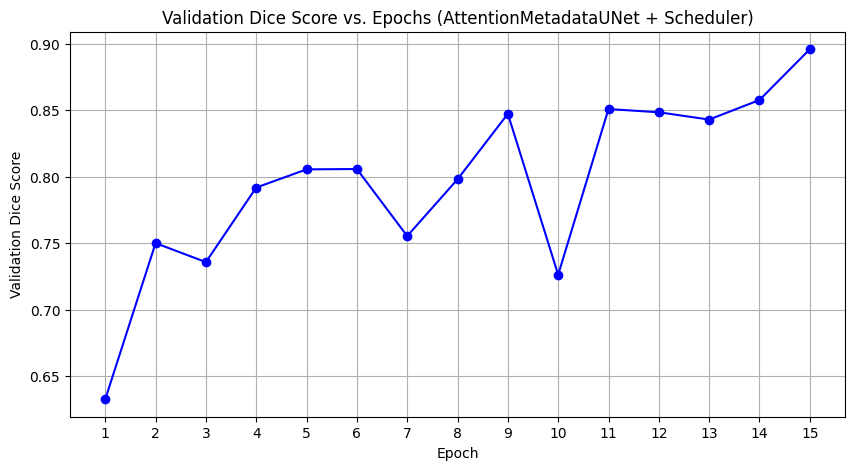

In [21]:
def train_meta_model_with_scheduler(model, name):
    model = model.to(Config.DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)

    # Adding ReduceLROnPlateau scheduler
    # It will reduce the LR by half if the validation Dice score doesn't improve for 2 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

    criterion = DiceBCELoss()

    best_val_dice = 0.0
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    # Track history for plotting
    history = {'train_loss': [], 'val_dice': [], 'val_iou': [], 'lr': []}

    for epoch in range(Config.EPOCHS):
        model.train()
        train_loss = 0.0

        for imgs, metas, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{Config.EPOCHS}"):
            imgs = imgs.to(Config.DEVICE, non_blocking=True)
            metas = metas.to(Config.DEVICE, non_blocking=True)
            masks = masks.to(Config.DEVICE, non_blocking=True)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(imgs, metas)
                loss = criterion(outputs, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        model.eval()
        val_dice_total = 0.0
        val_iou_total = 0.0

        with torch.no_grad():
            for imgs, metas, masks in val_loader:
                imgs = imgs.to(Config.DEVICE, non_blocking=True)
                metas = metas.to(Config.DEVICE, non_blocking=True)
                masks = masks.to(Config.DEVICE, non_blocking=True)

                outputs = model(imgs, metas)
                probs = torch.sigmoid(outputs)

                dice, iou = calculate_metrics(masks.cpu().numpy(), probs.cpu().numpy())
                val_dice_total += dice
                val_iou_total += iou

        train_loss /= len(train_loader)
        val_dice = val_dice_total / len(val_loader)
        val_iou = val_iou_total / len(val_loader)

        # Step the scheduler based on validation Dice
        scheduler.step(val_dice)
        current_lr = optimizer.param_groups[0]['lr']

        # Record metrics
        history['train_loss'].append(train_loss)
        history['val_dice'].append(val_dice)
        history['val_iou'].append(val_iou)
        history['lr'].append(current_lr)

        print(
            f"Epoch {epoch+1}/{Config.EPOCHS} | "
            f"LR: {current_lr:.6f} | "
            f"Loss: {train_loss:.4f} | "
            f"Val Dice: {val_dice:.4f} | "
            f"Val IoU: {val_iou:.4f}"
        )

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), f"best_{name}_scheduler.pth")

    print(f"Best Val Dice for {name} (with scheduler): {best_val_dice:.4f}")
    model.load_state_dict(torch.load(f"best_{name}_scheduler.pth"))
    return model, history

print(f"Initializing AttentionMetadataUNet with {num_meta_features} tabular features for training with scheduler...")
attention_meta_unet_sched, sched_history = train_meta_model_with_scheduler(
    AttentionMetadataUNet(meta_features=num_meta_features),
    "AttentionMetadataUNet"
)

# Plot the Validation Dice Score progress
plt.figure(figsize=(10, 5))
plt.plot(range(1, Config.EPOCHS + 1), sched_history['val_dice'], marker='o', linestyle='-', color='b')
plt.title('Validation Dice Score vs. Epochs (AttentionMetadataUNet + Scheduler)')
plt.xlabel('Epoch')
plt.ylabel('Validation Dice Score')
plt.grid(True)
plt.xticks(range(1, Config.EPOCHS + 1))
plt.show()

# Model Evaluation
Throughout this project, we explored several techniques to segment Brain MRIs:
1. **BasicUNet:** A standard U-Net architecture relying purely on the spatial features of the MRI images.
2. **MetadataUNet:** We infused tabular patient metadata (like age, gender, and tumor location) by encoding it through an MLP and fusing it into the U-Net's bottleneck to provide global context.
3. **AttentionMetadataUNet:** We incorporated **Attention Gates** into the decoder's skip connections, allowing the network to selectively focus on relevant spatial features and suppress irrelevant background noise.
4. **AttentionMetadataUNet + LR Scheduler:** To combat potential overfitting and aid in convergence for the complex model, we introduced a `ReduceLROnPlateau` learning rate scheduler.

Below, we load the best weights for all 4 models and visually compare their predictions side-by-side on the validation set!

Loading all trained models for final showcase...


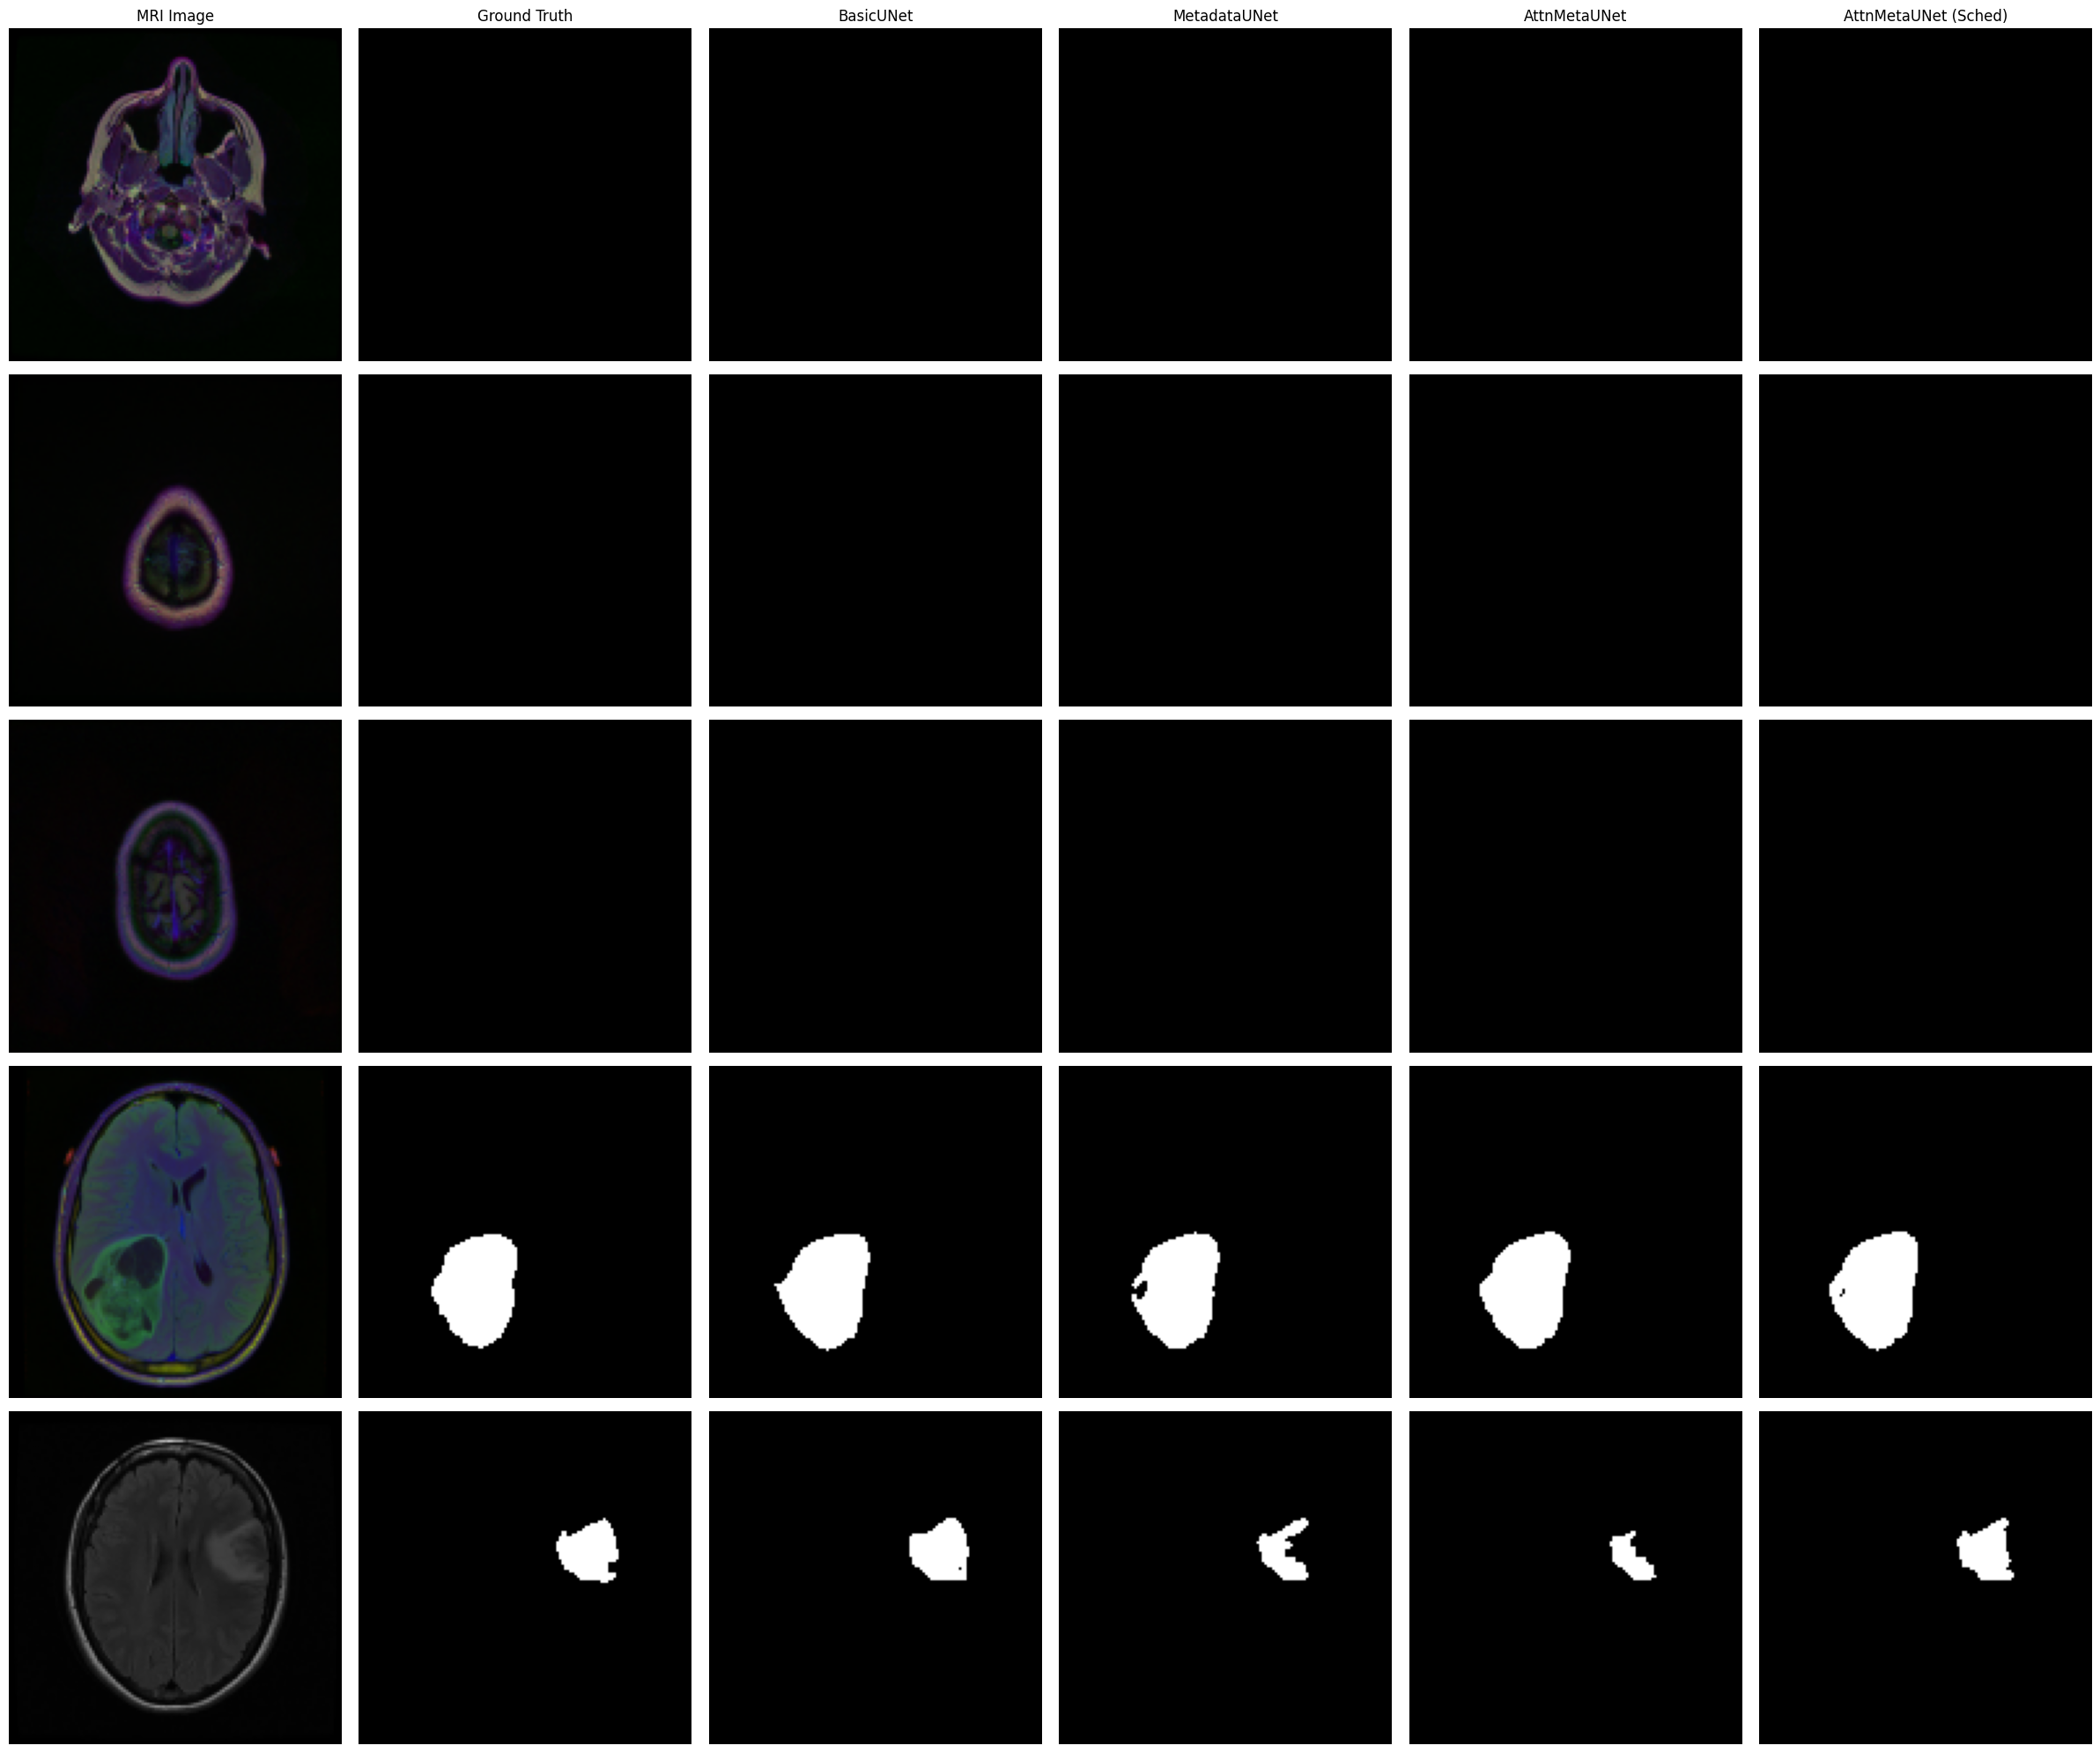

In [22]:
print("Loading all trained models for final showcase...")

basic_model = BasicUNet().to(Config.DEVICE)
basic_model.load_state_dict(torch.load("best_BasicUNet.pth"))
basic_model.eval()

meta_model = MetadataUNet(meta_features=num_meta_features).to(Config.DEVICE)
meta_model.load_state_dict(torch.load("best_MetadataUNet.pth"))
meta_model.eval()

attn_meta_model = AttentionMetadataUNet(meta_features=num_meta_features).to(Config.DEVICE)
attn_meta_model.load_state_dict(torch.load("best_AttentionMetadataUNet.pth"))
attn_meta_model.eval()

attn_meta_model_sched = AttentionMetadataUNet(meta_features=num_meta_features).to(Config.DEVICE)
attn_meta_model_sched.load_state_dict(torch.load("best_AttentionMetadataUNet_scheduler.pth"))
attn_meta_model_sched.eval()

def final_visual_showcase(dataset, num_samples=5):
    plt.figure(figsize=(24, num_samples * 4))

    # Randomly select samples or just take the first few
    # For consistency, we take the first 'num_samples' from the validation set
    for i in range(num_samples):
        img, meta, mask = dataset[i]

        with torch.no_grad():
            # 1. BasicUNet (expects only img)
            pred1 = torch.sigmoid(basic_model(img.unsqueeze(0).to(Config.DEVICE))).squeeze().cpu().numpy()

            # 2. MetadataUNet (expects img and meta)
            pred2 = torch.sigmoid(meta_model(img.unsqueeze(0).to(Config.DEVICE), meta.unsqueeze(0).to(Config.DEVICE))).squeeze().cpu().numpy()

            # 3. AttentionMetadataUNet
            pred3 = torch.sigmoid(attn_meta_model(img.unsqueeze(0).to(Config.DEVICE), meta.unsqueeze(0).to(Config.DEVICE))).squeeze().cpu().numpy()

            # 4. AttentionMetadataUNet + Scheduler
            pred4 = torch.sigmoid(attn_meta_model_sched(img.unsqueeze(0).to(Config.DEVICE), meta.unsqueeze(0).to(Config.DEVICE))).squeeze().cpu().numpy()

        img_np = np.transpose(img.numpy(), (1, 2, 0))
        mask_np = mask.squeeze().numpy()

        # Plotting
        plt.subplot(num_samples, 6, i * 6 + 1)
        plt.imshow(img_np)
        if i == 0: plt.title("MRI Image")
        plt.axis("off")

        plt.subplot(num_samples, 6, i * 6 + 2)
        plt.imshow(mask_np, cmap="gray")
        if i == 0: plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(num_samples, 6, i * 6 + 3)
        plt.imshow(pred1 > 0.5, cmap="gray")
        if i == 0: plt.title("BasicUNet")
        plt.axis("off")

        plt.subplot(num_samples, 6, i * 6 + 4)
        plt.imshow(pred2 > 0.5, cmap="gray")
        if i == 0: plt.title("MetadataUNet")
        plt.axis("off")

        plt.subplot(num_samples, 6, i * 6 + 5)
        plt.imshow(pred3 > 0.5, cmap="gray")
        if i == 0: plt.title("AttnMetaUNet")
        plt.axis("off")

        plt.subplot(num_samples, 6, i * 6 + 6)
        plt.imshow(pred4 > 0.5, cmap="gray")
        if i == 0: plt.title("AttnMetaUNet (Sched)")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Run the showcase
final_visual_showcase(val_dataset, num_samples=5)

In [23]:
def evaluate_all_models(val_loader):
    models = [
        ("BasicUNet", basic_model, False),
        ("MetadataUNet", meta_model, True),
        ("AttentionMetadataUNet", attn_meta_model, True),
        ("AttentionMetadataUNet (Scheduler)", attn_meta_model_sched, True)
    ]

    results = []
    for name, model, uses_meta in models:
        model.eval()
        dice_total, iou_total = 0.0, 0.0

        with torch.no_grad():
            for imgs, metas, masks in tqdm(val_loader, desc=f"Evaluating {name}"):
                imgs = imgs.to(Config.DEVICE)
                masks_np = masks.numpy()

                if uses_meta:
                    metas = metas.to(Config.DEVICE)
                    outputs = model(imgs, metas)
                else:
                    outputs = model(imgs)

                probs = torch.sigmoid(outputs).cpu().numpy()
                dice, iou = calculate_metrics(masks_np, probs)
                dice_total += dice
                iou_total += iou

        avg_dice = dice_total / len(val_loader)
        avg_iou = iou_total / len(val_loader)
        results.append({"Model": name, "Dice Score": avg_dice, "IoU Score": avg_iou})

    return pd.DataFrame(results)

print("Evaluating all models to get final Dice and IoU scores...")
final_metrics_df = evaluate_all_models(val_loader)
display(final_metrics_df)

Evaluating all models to get final Dice and IoU scores...


Evaluating AttentionMetadataUNet (Scheduler): 100%|██████████| 50/50 [00:04<00:00, 11.08it/s]


,Model,Dice Score,IoU Score
0,BasicUNet,0.894113,0.810121
1,MetadataUNet,0.894860,0.811078
2,AttentionMetadataUNet,0.871776,0.775612
3,AttentionMetadataUNet (Scheduler),0.895969,0.813479


# Dashboard Data

In [24]:
EXPORT_DIR = 'dashboard_data'
os.makedirs(EXPORT_DIR, exist_ok=True)
print(f'Export directory: {os.path.abspath(EXPORT_DIR)}')


Export directory: /content/dashboard_data


In [25]:
training_histories = {
    'BasicUNet': {
        'epochs': list(range(1, 16)),
        'train_loss': [0.8580, 0.3910, 0.3268, 0.2771, 0.2447, 0.2241, 0.2055, 0.2001, 0.1862, 0.1694, 0.1539, 0.1456, 0.1726, 0.1365, 0.1127],
        'val_dice':   [0.4905, 0.6742, 0.7156, 0.7451, 0.7459, 0.7788, 0.8089, 0.8000, 0.8431, 0.8271, 0.8197, 0.8526, 0.8426, 0.8404, 0.8931],
        'val_iou':    [0.3341, 0.5170, 0.5691, 0.5999, 0.6030, 0.6452, 0.6843, 0.6724, 0.7335, 0.7103, 0.6996, 0.7470, 0.7322, 0.7285, 0.8085],
        'best_dice': 0.8931,
        'best_epoch': 15
    },
    'MetadataUNet': {
        'epochs': list(range(1, 16)),
        'train_loss': [0.5540, 0.2984, 0.2416, 0.2206, 0.1994, 0.1903, 0.1676, 0.1604, 0.1478, 0.1583, 0.1484, 0.1339, 0.1311, 0.1125, 0.1042],
        'val_dice':   [0.7103, 0.7501, 0.7815, 0.8097, 0.8078, 0.8209, 0.8332, 0.7956, 0.8525, 0.8511, 0.8678, 0.8660, 0.8547, 0.8949, 0.8911],
        'val_iou':    [0.5602, 0.6079, 0.6479, 0.6862, 0.6824, 0.7024, 0.7188, 0.6692, 0.7476, 0.7449, 0.7693, 0.7672, 0.7514, 0.8111, 0.8057],
        'best_dice': 0.8949,
        'best_epoch': 14
    },
    'AttentionMetadataUNet': {
        'epochs': list(range(1, 16)),
        'train_loss': [0.6151, 0.2875, 0.2474, 0.2335, 0.2181, 0.2089, 0.1892, 0.1808, 0.1795, 0.1832, 0.1587, 0.1519, 0.1424, 0.1415, 0.1309],
        'val_dice':   [0.6983, 0.6101, 0.7729, 0.7800, 0.8078, 0.8035, 0.8258, 0.8117, 0.8275, 0.8423, 0.8383, 0.8620, 0.8418, 0.8677, 0.8718],
        'val_iou':    [0.5492, 0.4475, 0.6367, 0.6463, 0.6831, 0.6773, 0.7090, 0.6893, 0.7105, 0.7326, 0.7264, 0.7604, 0.7316, 0.7698, 0.7756],
        'best_dice': 0.8718,
        'best_epoch': 15
    },
    'AttentionMetadataUNet_Scheduler': {
        'epochs': list(range(1, 16)),
        'train_loss': [0.6138, 0.3063, 0.2644, 0.2339, 0.2139, 0.1981, 0.1849, 0.1732, 0.1563, 0.1631, 0.1712, 0.1366, 0.1453, 0.1305, 0.1172],
        'val_dice':   [0.6325, 0.7500, 0.7357, 0.7919, 0.8055, 0.8058, 0.7554, 0.7981, 0.8474, 0.7262, 0.8509, 0.8485, 0.8430, 0.8577, 0.8960],
        'val_iou':    [0.4760, 0.6089, 0.5889, 0.6629, 0.6811, 0.6814, 0.6149, 0.6719, 0.7392, 0.5827, 0.7456, 0.7412, 0.7334, 0.7551, 0.8135],
        'lr':         [0.001]*15,
        'best_dice': 0.8960,
        'best_epoch': 15
    }
}

with open(os.path.join(EXPORT_DIR, 'training_histories.json'), 'w') as f:
    json.dump(training_histories, f, indent=2)

print('Saved: training_histories.json')


Saved: training_histories.json


In [26]:
final_metrics = pd.DataFrame([
    {'Model': 'BasicUNet',                          'Dice': 0.894113, 'IoU': 0.810121, 'Uses_Metadata': False, 'Has_Attention': False, 'Has_Scheduler': False},
    {'Model': 'MetadataUNet',                       'Dice': 0.894860, 'IoU': 0.811078, 'Uses_Metadata': True,  'Has_Attention': False, 'Has_Scheduler': False},
    {'Model': 'AttentionMetadataUNet',              'Dice': 0.871776, 'IoU': 0.775612, 'Uses_Metadata': True,  'Has_Attention': True,  'Has_Scheduler': False},
    {'Model': 'AttentionMetadataUNet (Scheduler)',   'Dice': 0.895969, 'IoU': 0.813479, 'Uses_Metadata': True,  'Has_Attention': True,  'Has_Scheduler': True},
])

final_metrics.to_csv(os.path.join(EXPORT_DIR, 'final_model_comparison.csv'), index=False)
print('Saved: final_model_comparison.csv')
display(final_metrics)


Saved: final_model_comparison.csv


,Model,Dice,IoU,Uses_Metadata,Has_Attention,Has_Scheduler
0,BasicUNet,0.894113,0.810121,False,False,False
1,MetadataUNet,0.894860,0.811078,True,False,False
2,AttentionMetadataUNet,0.871776,0.775612,True,True,False
3,AttentionMetadataUNet (Scheduler),0.895969,0.813479,True,True,True


In [27]:
feature_column_mapping = {
    'num_features': 20,
    'columns': [
        'age_at_initial_pathologic',  # idx 0  (StandardScaled float)
        'gender_1.0',                 # idx 1  (Male)
        'gender_2.0',                 # idx 2  (Female)
        'histological_type_1.0',      # idx 3  (astrocytoma)
        'histological_type_2.0',      # idx 4  (oligoastrocytoma)
        'histological_type_3.0',      # idx 5  (oligodendroglioma)
        'tumor_location_1.0',         # idx 6
        'tumor_location_2.0',         # idx 7  (frontal lobe - most common)
        'tumor_location_4.0',         # idx 8
        'tumor_location_5.0',         # idx 9  (parietal lobe)
        'tumor_location_6.0',         # idx 10 (temporal lobe)
        'RNASeqCluster_1.0',          # idx 11
        'RNASeqCluster_2.0',          # idx 12
        'RNASeqCluster_3.0',          # idx 13
        'RNASeqCluster_4.0',          # idx 14
        'MethylationCluster_1.0',     # idx 15
        'MethylationCluster_2.0',     # idx 16
        'MethylationCluster_3.0',     # idx 17
        'MethylationCluster_4.0',     # idx 18
        'MethylationCluster_5.0',     # idx 19
    ],
    'categorical_labels': {
        'gender':            {'MALE': 'gender_1.0', 'FEMALE': 'gender_2.0'},
        'histological_type': {'astrocytoma': 'histological_type_1.0', 'oligoastrocytoma': 'histological_type_2.0', 'oligodendroglioma': 'histological_type_3.0'},
        'tumor_location':    {'other_1': 'tumor_location_1.0', 'frontal lobe': 'tumor_location_2.0', 'other_4': 'tumor_location_4.0', 'parietal lobe': 'tumor_location_5.0', 'temporal lobe': 'tumor_location_6.0'},
        'RNASeqCluster':     {'1': 'RNASeqCluster_1.0', '2': 'RNASeqCluster_2.0', '3': 'RNASeqCluster_3.0', '4': 'RNASeqCluster_4.0'},
        'MethylationCluster':{'1': 'MethylationCluster_1.0', '2': 'MethylationCluster_2.0', '3': 'MethylationCluster_3.0', '4': 'MethylationCluster_4.0', '5': 'MethylationCluster_5.0'}
    },
    'scaler_mean': float(scaler.mean_[0]),
    'scaler_scale': float(scaler.scale_[0])
}

with open(os.path.join(EXPORT_DIR, 'feature_mapping.json'), 'w') as f:
    json.dump(feature_column_mapping, f, indent=2)

# Also re-save the scaler
joblib.dump(scaler, os.path.join(EXPORT_DIR, 'scaler.joblib'))

print('Saved: feature_mapping.json, scaler.joblib')


Saved: feature_mapping.json, scaler.joblib


In [28]:
models_to_eval = [
    ('BasicUNet', basic_model, False),
    ('MetadataUNet', meta_model, True),
    ('AttentionMetadataUNet', attn_meta_model, True),
    ('AttentionMetadataUNet_Scheduler', attn_meta_model_sched, True)
]

per_sample_results = []

for model_name, model, uses_meta in models_to_eval:
    model.eval()
    for idx in tqdm(range(len(val_dataset)), desc=f'Per-sample eval: {model_name}'):
        img, meta, mask = val_dataset[idx]
        with torch.no_grad():
            img_gpu = img.unsqueeze(0).to(Config.DEVICE)
            if uses_meta:
                meta_gpu = meta.unsqueeze(0).to(Config.DEVICE)
                pred = torch.sigmoid(model(img_gpu, meta_gpu)).squeeze().cpu().numpy()
            else:
                pred = torch.sigmoid(model(img_gpu)).squeeze().cpu().numpy()

        mask_np = mask.squeeze().numpy()
        dice, iou = calculate_metrics(mask_np, pred)
        has_tumor = int(mask_np.sum() > 0)
        confidence = float(np.mean(pred[pred > 0.5])) if (pred > 0.5).any() else 0.0

        # Extract patient ID from file path
        patient_id = os.path.basename(os.path.dirname(val_imgs[idx]))

        per_sample_results.append({
            'model': model_name,
            'sample_idx': idx,
            'patient_id': patient_id,
            'has_tumor': has_tumor,
            'dice': round(dice, 4),
            'iou': round(iou, 4),
            'avg_confidence': round(confidence, 4)
        })

df_per_sample = pd.DataFrame(per_sample_results)
df_per_sample.to_csv(os.path.join(EXPORT_DIR, 'per_sample_scores.csv'), index=False)

print(f'Saved: per_sample_scores.csv ({len(df_per_sample)} rows)')


Per-sample eval: AttentionMetadataUNet_Scheduler: 100%|██████████| 1572/1572 [00:12<00:00, 131.00it/s]


Saved: per_sample_scores.csv (6288 rows)

Summary by model:


,dice,iou
model,,
AttentionMetadataUNet,0.902692,0.877700
AttentionMetadataUNet_Scheduler,0.922279,0.895902
BasicUNet,0.922420,0.896932
MetadataUNet,0.920333,0.893691


In [29]:
gallery_dir = os.path.join(EXPORT_DIR, 'gallery')
os.makedirs(gallery_dir, exist_ok=True)

# Pick 10 samples: 5 with tumor, 5 without (or as many as available)
tumor_indices = [i for i in range(len(val_dataset)) if val_dataset[i][2].sum() > 0]
no_tumor_indices = [i for i in range(len(val_dataset)) if val_dataset[i][2].sum() == 0]

sample_indices = tumor_indices[:5] + no_tumor_indices[:5]
best_model = attn_meta_model_sched  # Best performing model
best_model.eval()

for idx in sample_indices:
    img, meta, mask = val_dataset[idx]
    with torch.no_grad():
        pred = torch.sigmoid(
            best_model(img.unsqueeze(0).to(Config.DEVICE), meta.unsqueeze(0).to(Config.DEVICE))
        ).squeeze().cpu().numpy()

    img_np = (np.transpose(img.numpy(), (1, 2, 0)) * 255).astype(np.uint8)
    mask_np = (mask.squeeze().numpy() * 255).astype(np.uint8)
    pred_np = ((pred > 0.5).astype(np.float32) * 255).astype(np.uint8)

    # Create overlay
    overlay = img_np.copy()
    overlay[pred > 0.5] = [0, 255, 127]
    blended = cv2.addWeighted(overlay, 0.4, img_np, 0.6, 0)

    patient_id = os.path.basename(os.path.dirname(val_imgs[idx]))
    cv2.imwrite(os.path.join(gallery_dir, f'{patient_id}_{idx}_mri.png'), cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(gallery_dir, f'{patient_id}_{idx}_mask_gt.png'), mask_np)
    cv2.imwrite(os.path.join(gallery_dir, f'{patient_id}_{idx}_mask_pred.png'), pred_np)
    cv2.imwrite(os.path.join(gallery_dir, f'{patient_id}_{idx}_overlay.png'), cv2.cvtColor(blended, cv2.COLOR_RGB2BGR))

print(f'Saved {len(sample_indices)} sample sets to {gallery_dir}/')


Saved 10 sample sets to dashboard_data/gallery/


In [30]:
# Read raw CSV for stats
data_csv_path = None
for dirpath, _, filenames in os.walk(Config.DATA_PATH):
    if 'data.csv' in filenames:
        data_csv_path = os.path.join(dirpath, 'data.csv')
        break

df_raw = pd.read_csv(data_csv_path)

# Tumor coverage per patient (% of mask pixels)
patient_tumor_coverage = []
for idx in range(len(val_dataset)):
    _, _, mask = val_dataset[idx]
    mask_np = mask.squeeze().numpy()
    coverage = float(mask_np.sum() / mask_np.size * 100)
    patient_id = os.path.basename(os.path.dirname(val_imgs[idx]))
    patient_tumor_coverage.append({'patient_id': patient_id, 'sample_idx': idx, 'tumor_coverage_pct': round(coverage, 2)})

df_coverage = pd.DataFrame(patient_tumor_coverage)
df_coverage.to_csv(os.path.join(EXPORT_DIR, 'tumor_coverage.csv'), index=False)

dataset_stats = {
    'total_samples': len(all_imgs),
    'train_samples': len(train_imgs),
    'val_samples': len(val_imgs),
    'num_patients': len(df_raw),
    'image_size': list(Config.IMAGE_SIZE),
    'batch_size': Config.BATCH_SIZE,
    'epochs': Config.EPOCHS,
    'learning_rate': Config.LEARNING_RATE,
    'loss_function': 'DiceBCE (BCE + Dice)',
    'optimizer': 'Adam',
    'mixed_precision': True,
    'val_tumor_slices': int(df_coverage[df_coverage['tumor_coverage_pct'] > 0].shape[0]),
    'val_clean_slices': int(df_coverage[df_coverage['tumor_coverage_pct'] == 0].shape[0]),
    'avg_tumor_coverage_pct': round(df_coverage[df_coverage['tumor_coverage_pct'] > 0]['tumor_coverage_pct'].mean(), 2),
    'metadata_columns_used': ['age_at_initial_pathologic', 'gender', 'histological_type', 'tumor_location', 'RNASeqCluster', 'MethylationCluster'],
    'all_csv_columns': list(df_raw.columns)
}

with open(os.path.join(EXPORT_DIR, 'dataset_stats.json'), 'w') as f:
    json.dump(dataset_stats, f, indent=2)

print('Saved: dataset_stats.json, tumor_coverage.csv')
print(json.dumps(dataset_stats, indent=2))


Saved: dataset_stats.json, tumor_coverage.csv
{
  "total_samples": 7858,
  "train_samples": 6286,
  "val_samples": 1572,
  "num_patients": 110,
  "image_size": [
    128,
    128
  ],
  "batch_size": 32,
  "epochs": 15,
  "learning_rate": 0.001,
  "loss_function": "DiceBCE (BCE + Dice)",
  "optimizer": "Adam",
  "mixed_precision": true,
  "val_tumor_slices": 535,
  "val_clean_slices": 1037,
  "avg_tumor_coverage_pct": 3.0,
  "metadata_columns_used": [
    "age_at_initial_pathologic",
    "gender",
    "histological_type",
    "tumor_location",
    "RNASeqCluster",
    "MethylationCluster"
  ],
  "all_csv_columns": [
    "Patient",
    "RNASeqCluster",
    "MethylationCluster",
    "miRNACluster",
    "CNCluster",
    "RPPACluster",
    "OncosignCluster",
    "COCCluster",
    "histological_type",
    "neoplasm_histologic_grade",
    "tumor_tissue_site",
    "laterality",
    "tumor_location",
    "gender",
    "age_at_initial_pathologic",
    "race",
    "ethnicity",
    "death01"
  ]


In [31]:
model_files = [
    'best_BasicUNet.pth',
    'best_MetadataUNet.pth',
    'best_AttentionMetadataUNet.pth',
    'best_AttentionMetadataUNet_scheduler.pth'
]

models_dir = os.path.join(EXPORT_DIR, 'models')
os.makedirs(models_dir, exist_ok=True)

for mf in model_files:
    if os.path.exists(mf):
        shutil.copy2(mf, os.path.join(models_dir, mf))
        print(f'  Copied: {mf}')
    else:
        print(f'  MISSING: {mf}')

print('\n' + '='*50)
print('EXPORT COMPLETE — Dashboard Data Package')
print('='*50)
for root, dirs, files in os.walk(EXPORT_DIR):
    level = root.replace(EXPORT_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files:
        size = os.path.getsize(os.path.join(root, f))
        size_str = f'{size/1024:.1f} KB' if size < 1024*1024 else f'{size/1024/1024:.1f} MB'
        print(f'{indent}  {f} ({size_str})')


  Copied: best_BasicUNet.pth
  Copied: best_MetadataUNet.pth
  Copied: best_AttentionMetadataUNet.pth
  Copied: best_AttentionMetadataUNet_scheduler.pth

EXPORT COMPLETE — Dashboard Data Package
dashboard_data/
  dataset_stats.json (0.9 KB)
  training_histories.json (3.9 KB)
  scaler.joblib (0.9 KB)
  feature_mapping.json (1.5 KB)
  per_sample_scores.csv (382.2 KB)
  final_model_comparison.csv (0.3 KB)
  tumor_coverage.csv (47.0 KB)
  gallery/
    TCGA_HT_A616_19991226_4_mask_pred.png (0.3 KB)
    TCGA_HT_7877_19980917_10_mask_gt.png (0.3 KB)
    TCGA_FG_6689_20020326_14_mri.png (23.7 KB)
    TCGA_DU_A5TY_19970709_0_mri.png (22.7 KB)
    TCGA_DU_A5TY_19970709_0_mask_gt.png (0.2 KB)
    TCGA_DU_A5TY_19970709_0_overlay.png (22.7 KB)
    TCGA_CS_6665_20010817_6_mri.png (16.7 KB)
    TCGA_HT_A616_19991226_4_mask_gt.png (0.3 KB)
    TCGA_HT_7881_19981015_1_mri.png (14.8 KB)
    TCGA_FG_7643_20021104_2_mri.png (19.5 KB)
    TCGA_DU_5853_19950823_5_mri.png (18.8 KB)
    TCGA_DU_5853_19950823_

In [36]:
output_zip_filename = 'dashboard_data.zip'

with zipfile.ZipFile(output_zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files_in_dir in os.walk(EXPORT_DIR):
        for file in files_in_dir:
            file_path = os.path.join(root, file)
            # Add file to zip, preserving directory structure within the zip
            zipf.write(file_path, os.path.relpath(file_path, EXPORT_DIR))

print(f'Successfully created {output_zip_filename}.')

files.download(output_zip_filename)
print(f'{output_zip_filename} is ready for download.')

Successfully created dashboard_data.zip.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

dashboard_data.zip is ready for download.
